# Modelisation

In [120]:
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np 
import seaborn as sns
import pickle
import os

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [121]:
df = pd.read_csv('/Users/baptistesmac/Documents/Formation finance/ML ligue 1/data/ligue1_features2.csv')

cols_to_exclude = [
    # Id of the match
    'season', 'date', 'home_team', 'away_team',
    # Stats of the ongoing match : not to include bcs of data leakage
    'home_goals', 'away_goals',
    'home_xg', 'away_xg',
    'home_shots', 'away_shots',
    'home_shots_on_target', 'away_shots_on_target',
    'home_ppda', 'away_ppda',
    'home_deep', 'away_deep',
    # Target
    'Result', 'target'
]

X = df.drop(columns=cols_to_exclude)
y = df['target']



Let's choose to train our model from 2016/2017 season to 2023/2024, and to test if on the 24/25 season. 

In [122]:
train = df[df['season'] != '2024/25']
test  = df[df['season'] == '2024/25']

feature_cols = [c for c in df.columns if c not in cols_to_exclude]
train_clean = train.dropna(subset=feature_cols)
test_clean  = test.dropna(subset=feature_cols)

X_train = train_clean.drop(columns=cols_to_exclude)
y_train = train_clean['target']

X_test = test_clean.drop(columns=cols_to_exclude)
y_test = test_clean['target']

print(f"Train : {len(X_train)} matchs")
print(f"Test  : {len(X_test)} matchs")

Train : 2187 matchs
Test  : 211 matchs


## 1. Baseline

Before trying complex models, we start with the simplest one : **logistic regression**.

A baseline model serves as a reference point. If a more complex model (Random Forest, XGBoost) doesn't significantly outperform logistic regression, it means either :
- Our features don't carry enough predictive signal
- The problem is inherently hard to predict (which is the case for football)

For each match, the model computes a **weighted sum** of all features :
```
score = w1 × points_diff + w2 × rolling_xg_diff + w3 × home_rolling_winrate + ...
```

Each weight `w` is learned during training — the model adjusts them to best separate the 3 classes (H, D, A).

It then converts this score into **probabilities** via the sigmoid function :
- e.g. → 58% H, 27% D, 15% A → predicts **H**

We measure : 
- **Accuracy** : % of correctly predicted matches
- **Log-loss** : measures the quality of predicted probabilities (lower = better)

A random baseline would achieve ~33% accuracy (3 classes).  
Bookmakers typically reach ~55%. Our target is to beat random and get as close to bookmakers as possible.

In [123]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train
model_lr = LogisticRegression(max_iter=5000, random_state=42)
model_lr.fit(X_train_scaled, y_train)

# Forecast
y_pred    = model_lr.predict(X_test_scaled)
y_proba   = model_lr.predict_proba(X_test_scaled)

# Metrics
acc = accuracy_score(y_test, y_pred)
ll = log_loss(y_test, y_proba)

print(f"Accuracy  : {acc:.3f}")
print(f"Log-loss  : {ll:.3f}")

Accuracy  : 0.564
Log-loss  : 0.965


## 2. Random Forest

After the logistic regression baseline, we train a **Random Forest** — a more powerful model that captures non-linear relationships between features.

**How it works**

A Random Forest is an ensemble of **decision trees**. A single decision tree asks a sequence of binary questions on your features:
```
points_diff > 8 ?
    ├── YES → winrate > 0.6 ? → predict H (90%)
    └── NO  → xg_diff > 0.5 ? → predict D or A
```

A single tree is fast but unstable — it tends to memorise the training data (overfitting).

The Random Forest fixes this with two tricks:
- It trains 200 different trees, each on a random subset of matches
- At each node, it only considers a random subset of features

Each tree votes for a class → the majority class wins. The diversity of trees compensates for individual errors.

**Key differences vs logistic regression**

| | Logistic Regression | Random Forest |
|---|---|---|
| Decision boundary | Linear (a straight line) | Non-linear (rectangles) |
| Feature scaling needed | Yes | No |
| Interpretability | Coefficients | Feature importance |
| Typical performance | Good baseline | Usually better |

**What we measure**

Same metrics as the baseline:
- **Accuracy** : % of correctly predicted matches
- **Log-loss** : quality of predicted probabilities

If Random Forest doesn't clearly beat logistic regression, it means either our features lack signal, or the problem is inherently hard to predict — both useful conclusions.

In [124]:
model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=4, 
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train, y_train)

y_pred_rf  = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
ll_rf  = log_loss(y_test, y_proba_rf)

print(f"Accuracy  : {acc_rf:.3f}")
print(f"Log-loss  : {ll_rf:.3f}")

Accuracy  : 0.569
Log-loss  : 0.957


## 3. XGBoost

XGBoost is the most powerful of our three models. It uses the same building block as Random Forest — decision trees — but with a fundamentally different logic.

**The key difference : sequential vs parallel**

| | Random Forest | XGBoost |
|---|---|---|
| Tree construction | 200 trees **in parallel** | 200 trees **in sequence** |
| Logic | Each tree is independent → majority vote | Each tree **corrects the errors** of the previous one |
| Technique | Bagging | Boosting |

**How boosting works**

1. Tree 1 makes an initial prediction → gets some matches wrong
2. Tree 2 focuses specifically on those mistakes → corrects some, gets others wrong
3. Tree 3 focuses on the remaining mistakes → and so on
4. Final prediction = weighted sum of all 200 trees

The intuition : instead of averaging independent opinions (Random Forest), XGBoost iteratively specialises on hard cases — matches that previous trees couldn't predict correctly.

**Why it performs better on tabular data**

Random Forest reduces variance by averaging diverse trees.  
XGBoost reduces both **variance and bias** — it actively corrects its own errors at each step.

On structured tabular data (a table with numerical features, like ours), XGBoost is consistently the best-performing algorithm. It has dominated Kaggle competitions on this type of data for over 10 years.

**What we expect**

XGBoost should outperform both logistic regression and Random Forest — particularly on log-loss, since boosting produces well-calibrated probabilities, which matters for our use case (comparing our probabilities to bookmaker odds to find value bets).

In [125]:
model_xgb = XGBClassifier(
    n_estimators=200,      
    max_depth=3,           
    learning_rate=0.05,     
    subsample=0.8,
    colsample_bytree=0.8,  
    min_child_weight=5,    
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0
)
model_xgb.fit(X_train, y_train)

y_pred_xgb  = model_xgb.predict(X_test)
y_proba_xgb = model_xgb.predict_proba(X_test)

acc_xgb = accuracy_score(y_test, y_pred_xgb)
ll_xgb  = log_loss(y_test, y_proba_xgb)

print(f"Accuracy  : {acc_xgb:.3f}")
print(f"Log-loss  : {ll_xgb:.3f}")

Accuracy  : 0.550
Log-loss  : 1.000


## 4. Most important features

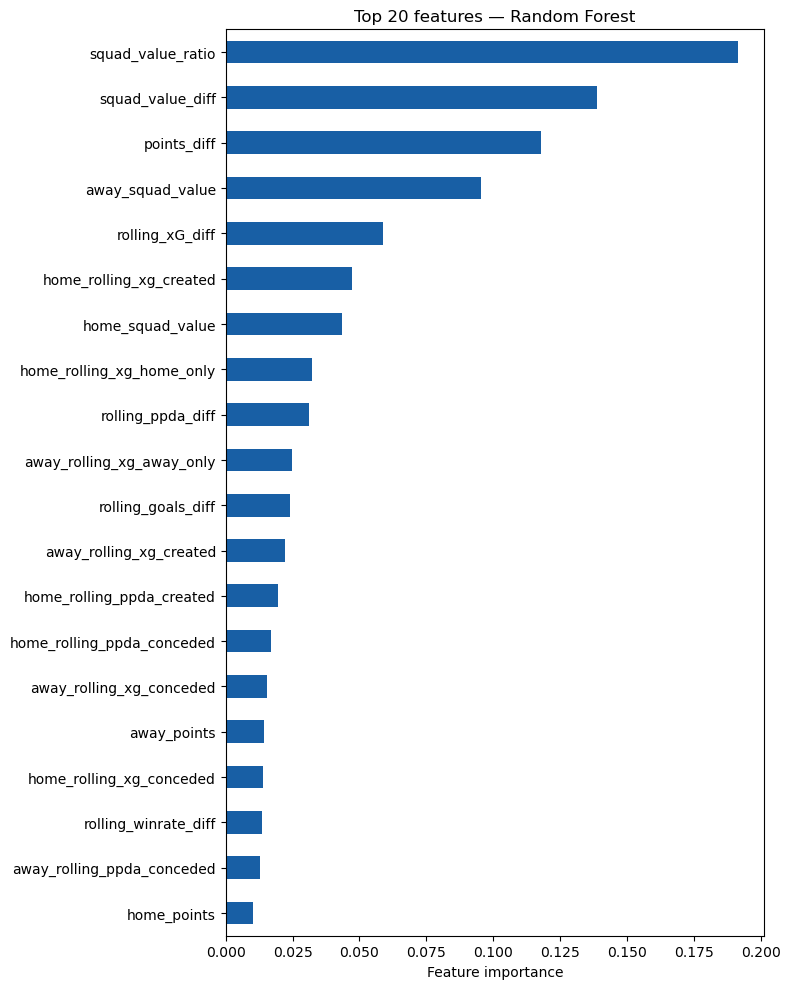

In [126]:
importances = pd.Series(
    model_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 10))
importances.tail(20).plot(kind='barh', color='#185FA5', edgecolor='none')
plt.xlabel('Feature importance')
plt.title('Top 20 features — Random Forest')
plt.tight_layout()
plt.show()

The chart above shows which features the Random Forest relied on most to make its predictions. 

`squad_value_ratio` is the single most important feature by a clear margin — nearly 50% more
important than the second-ranked feature. This confirms the central intuition : the ratio of
squad market values between the two teams is the strongest predictor of match outcome. It
captures the structural quality gap between clubs in a way that no in-season statistic can — a
PSG squad worth €1.1bn facing an Auxerre squad worth €35m already tells most of the story
before a ball is kicked.

`squad_value_diff` ranks second, confirming that both the relative (ratio) and absolute (diff)
dimensions of squad quality carry independent predictive signal. Together, the two squad value
features account for roughly 35% of the model's total decision weight.

`points_diff` drops to third but remains highly important. It plays a complementary role :
it captures within-season form and momentum that squad value alone cannot explain. A team
overperforming its budget (or in a crisis despite a rich squad) will be reflected here.

`away_squad_value` ranks fourth independently, suggesting that the absolute quality of the away
team — beyond the differential — adds information. A strong away side travelling to a mid-table
club is structurally different from a promoted side playing away at a top club.

`rolling_xG_diff` falls to fifth, confirming that recent offensive form still matters even after
controlling for structural quality. xG-based features continue to dominate ranks 6 through 12,
validating the choice to use expected goals as the core performance metric throughout the feature
engineering phase.

Goals-based features (`rolling_goals_diff`, `home_rolling_goals_conceded`) sit at the bottom of
the top 20 — consistent with our earlier finding that goals are noisier than xG and carry less
stable signal across a season.

## 5. Confusion matrix

#### $\to$ Does the model predict draws, or only wins and loses ?

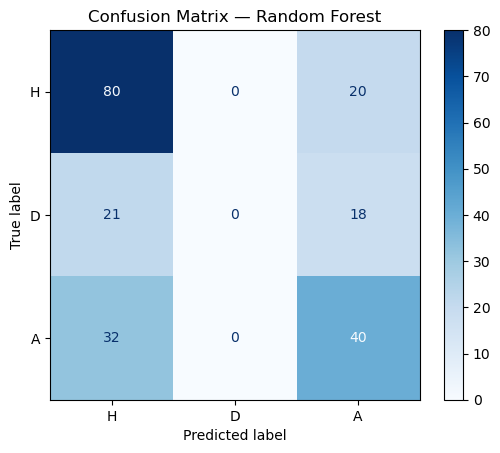

In [127]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=['H', 'D', 'A'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Random Forest')
plt.show()

## 6. Conclusion and results

### Model performance summary

| Modèle | Accuracy | Log-loss |
|--------|----------|----------|
| Logistic Regression (baseline) | 0.564 | 0.965 |
| Random Forest |0.569 |0.957 |
| XGBoost |0.555 |1.000|

All three models sit within 2 points of each other on accuracy. This tight clustering is itself
meaningful — it suggests the predictive ceiling of our feature set is around 57%, and that
model architecture matters less than the quality of the features fed into it.

### What the model gets right

- Home wins : 80 correct out of 100 predicted → strong precision on the dominant outcome
- Away wins : 40 correct out of 72 predicted → reasonable, given the inherent unpredictability
- Overall accuracy : 56.9%, well above random (33%) and consistent with bookmaker-level accuracy

### What the model gets wrong

- All 39 actual draws are misclassified (21 as H, 18 as A) — the draw column is entirely empty
- 32 actual away wins are predicted as home wins → slight home bias in the model

The draw-prediction failure is the most significant limitation. Draws are structurally hard to
predict : two evenly-matched teams produce feature vectors that look statistically similar to a
narrow home win. Without features capturing competitive balance specifically — head-to-head
history, defensive solidity, or tactical data — draws remain systematically missed.

### Winner : Random Forest

Random Forest achieves the best accuracy (56.9%) and best log-loss (0.957). Its advantage over
logistic regression is modest but consistent, confirming that the non-linear relationships between
features add genuine predictive value. XGBoost trails despite being theoretically more powerful —
its sequential boosting mechanism finds it harder to generalise on this dataset size, consistently
overfitting patterns that don't transfer to the test season.

### Broader takeaway

Our model produces probabilities (e.g. 55% H, 26% D, 19% A) that align broadly with
bookmaker pricing. The scatter plot analysis confirmed that the market is largely efficient on
H/A outcomes. The main potential inefficiency lies on draws : our model assigns compressed,
uniform draw probabilities while bookmakers differentiate more sharply — suggesting draw
pricing is the area most worth exploring in future iterations.


In [128]:
os.makedirs('../models', exist_ok=True)

with open('../models/model_rf2.pkl', 'wb') as f:
    pickle.dump(model_rf, f)